In [1]:
print('hello world')

hello world


In [3]:
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load the dataset
data = pd.read_csv("../dataset/role_prediction/resume_dataset.csv")

print("Dataset shape: ", data.shape)
print("\nColumns:")
print(data.columns)

print("\nFirst 5 rows of the dataset:")
print(data.head())

Dataset shape:  (2257, 7)

Columns:
Index(['id', 'category', 'skills', 'education', 'experience', 'text', 'html'], dtype='str')

First 5 rows of the dataset:
         id  category                                             skills  \
0  21614256  ADVOCATE  Word programs (including Excel and Access), EP...   
1  97405769  ADVOCATE  Superb sales professional, Store planning and ...   
2  95970987  ADVOCATE  Domestic Violence, Sexual Abuse, Rape, Prostit...   
3  17021141  ADVOCATE  Accounting, Cashiering, Coaching, Computer tra...   
4  15337481  ADVOCATE  Microsoft Suite Proficiency, RightFax Ventura,...   

                                           education  \
0  Boston University, Master of Public Health, Ep...   
1  William Penn Vo-tech, General-Business, High S...   
2  Boricua College, Human Services Psychology and...   
3  University of Phoenix - Master of Business Adm...   
4  El Centro Community College, Health Administra...   

                                          experi

In [5]:
data = data[['text', 'skills', 'education', 'experience', 'category']].copy()
data.fillna('', inplace=True)

print("Shape after keeping needed columns:", data.shape)
print(data.head())

Shape after keeping needed columns: (2257, 5)
                                                text  \
0           BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...   
1           CUSTOMER SERVICE ADVOCATE       Summa...   
2           CLINICAL SERVICE ADVOCATE       Profe...   
3           PH INPATIENT/FINANCIAL ADVOCATE SUPER...   
4           CUSTOMER SERVICE ADVOCATE       Summa...   

                                              skills  \
0  Word programs (including Excel and Access), EP...   
1  Superb sales professional, Store planning and ...   
2  Domestic Violence, Sexual Abuse, Rape, Prostit...   
3  Accounting, Cashiering, Coaching, Computer tra...   
4  Microsoft Suite Proficiency, RightFax Ventura,...   

                                           education  \
0  Boston University, Master of Public Health, Ep...   
1  William Penn Vo-tech, General-Business, High S...   
2  Boricua College, Human Services Psychology and...   
3  University of Phoenix - Master of Business Adm...   


category
BUSINESS-DEVELOPMENT      118
FINANCE                   118
ACCOUNTANT                117
FITNESS                   116
AVIATION                  116
HEALTHCARE                115
CONSULTANT                115
SALES                     114
CHEF                      114
ENGINEERING               114
BANKING                   114
HR                        112
PUBLIC-RELATIONS          110
CONSTRUCTION              109
DESIGNER                  105
ARTS                      102
APPAREL                    97
DIGITAL-MEDIA              93
INFORMATION-TECHNOLOGY     82
AGRICULTURE                62
ADVOCATE                   57
AUTOMOBILE                 36
BPO                        21
Name: count, dtype: int64


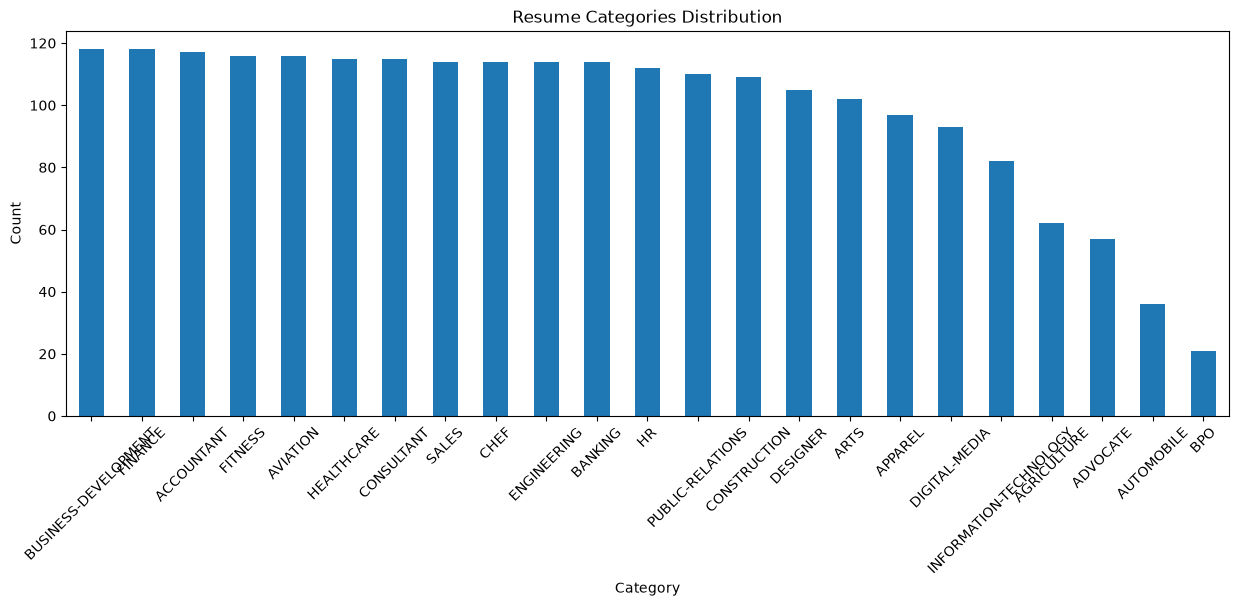

In [6]:
print(data['category'].value_counts())

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
data['category'].value_counts().plot(kind='bar')
plt.title("Resume Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [7]:
import re

def clean_resume(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text) # Remove URLs
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text) # Remove special characters
    text = re.sub(r'\s+', ' ', text) # Remove extra spaces
    return text

In [8]:
data['cleaned_resume'] = data['text'].apply(clean_resume)

print(data[['text', 'cleaned_resume']].head(3))

                                                text  \
0           BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...   
1           CUSTOMER SERVICE ADVOCATE       Summa...   
2           CLINICAL SERVICE ADVOCATE       Profe...   

                                      cleaned_resume  
0   bilingual domestic violence advocate skills w...  
1   customer service advocate summary talented cu...  
2   clinical service advocate professional summar...  


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['category'])

print("Number of categories:", len(label_encoder.classes_))
print("\nCategory mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category} -> {i}")

Number of categories: 23

Category mapping:
ACCOUNTANT -> 0
ADVOCATE -> 1
AGRICULTURE -> 2
APPAREL -> 3
ARTS -> 4
AUTOMOBILE -> 5
AVIATION -> 6
BANKING -> 7
BPO -> 8
BUSINESS-DEVELOPMENT -> 9
CHEF -> 10
CONSTRUCTION -> 11
CONSULTANT -> 12
DESIGNER -> 13
DIGITAL-MEDIA -> 14
ENGINEERING -> 15
FINANCE -> 16
FITNESS -> 17
HEALTHCARE -> 18
HR -> 19
INFORMATION-TECHNOLOGY -> 20
PUBLIC-RELATIONS -> 21
SALES -> 22


In [10]:
X = data['cleaned_resume']
y = data['label']

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Tranning samples:", len(x_train))
print("Tesging samples:", len(x_test))

Tranning samples: 1805
Tesging samples: 452


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

print("X_train_tfidf shape:", x_train_tfidf.shape)
print("X_test_tfidf shape:", x_test_tfidf.shape)

X_train_tfidf shape: (1805, 5000)
X_test_tfidf shape: (452, 5000)


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(x_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [20]:
y_pred = model.predict(x_test_tfidf)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 65.27 %
                        precision    recall  f1-score   support

            ACCOUNTANT       0.72      0.96      0.82        24
              ADVOCATE       0.50      0.09      0.15        11
           AGRICULTURE       1.00      0.17      0.29        12
               APPAREL       0.70      0.37      0.48        19
                  ARTS       0.56      0.50      0.53        20
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.84      0.70      0.76        23
               BANKING       0.73      0.70      0.71        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.53      0.88      0.66        24
                  CHEF       1.00      0.78      0.88        23
          CONSTRUCTION       0.81      0.77      0.79        22
            CONSULTANT       0.73      0.35      0.47        23
              DESIGNER       0.85      0.81      0.83        21
         DIGITAL-MEDI

c:\Users\ACER\OneDrive\เอกสาร\Projects\resume_screening_system\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\OneDrive\เอกสาร\Projects\resume_screening_system\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\OneDrive\เอกสาร\Projects\resume_screening_system\env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co

In [22]:
sample_resume = """
Python developer with experience in Flask, Django, REST APIs, MySQL,
machine learning, Git, HTML, CSS and JavaScript.
"""

sample_clean = clean_resume(sample_resume)
sample_vector = tfidf_vectorizer.transform([sample_clean])
predicted_label = model.predict(sample_vector)[0]
predicted_role = label_encoder.inverse_transform([predicted_label])[0]

print("Predicted Role:", predicted_role)

Predicted Role: ENGINEERING


In [23]:
import joblib

joblib.dump(model, "../model/role_model.pkl")
joblib.dump(tfidf_vectorizer, "../model/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../model/label_encoder.pkl")

print("Model, vectorizer, and label encoder saved successfully.")

Model, vectorizer, and label encoder saved successfully.
